In [1]:
# https://drive.google.com/file/d/10cyq2pvGMaHnCXR0rolTUwQ8TgsHKiEC/view?usp=sharing ?

#!gdown --id 10cyq2pvGMaHnCXR0rolTUwQ8TgsHKiEC -O vp.jpg


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib notebook

img = cv2.imread('vp.jpg')
# cv2_imshow(img)

In [3]:
def norm_points(p):
    r,c = p.shape
    for i in range(c):
        if p[-1,i] != 0:
            p[:,i] /= p[-1,i]
    return p

Definimos los puntos ideales de la reticula

In [4]:
#un cuadrado de 1x1

pr = np.ones((3,4))
#pr[:2,0] = [0., 5.]
#pr[:2,1] = [0., 0.]
#pr[:2,2] = [2.8, 0.]
#pr[:2,3] = [2.8, 5.]
pr[:2,0] = [0., 1]
pr[:2,1] = [0., 0.]
pr[:2,2] = [1, 0.]
pr[:2,3] = [1, 1.]

pr = norm_points(pr)

print("pr =\n", pr)

#Estas son las lineas de la reticula que pasan por los puntos pr.
lr = np.ones((3,4))
lr[:,0] = np.cross(pr[:,0], pr[:,1])
lr[:,1] = np.cross(pr[:,1], pr[:,2])
lr[:,2] = np.cross(pr[:,2], pr[:,3])
lr[:,3] = np.cross(pr[:,3], pr[:,0])


print("lr =\n", lr)

pr =
 [[0. 0. 1. 1.]
 [1. 0. 0. 1.]
 [1. 1. 1. 1.]]
lr =
 [[ 1.  0. -1.  0.]
 [ 0.  1.  0. -1.]
 [ 0.  0.  1.  1.]]


Definir puntos de fuga y puntos reales

In [5]:

# Definir puntos de fuga y puntos
vp1 = np.array([-3, 540, 1])
vp2 = np.array([1916, 540, 1])

p1 = np.array([114, 766, 1])
p2 = np.array([829, 677, 1])
p3 = np.array([1048, 716, 1])

blue_points = [p1, p2, p3]

# Calcular líneas
l = np.zeros((3, 4))
l[:, 0] = np.cross(vp1, p2)
l[:, 1] = np.cross(vp1, p1)
l[:, 2] = np.cross(vp2, p1)
l[:, 3] = np.cross(vp2, p3)

def norm_points(p):
    return p / p[-1]

# Calcular punto de intersección p4
p4 = np.cross(l[:, 1], l[:, 3])
p4 = norm_points(p4)

# Almacenar puntos en la matriz p
p = np.zeros((3, 4))
p[:, 0] = p1
p[:, 1] = p2
p[:, 2] = p3
p[:, 3] = p4
p = norm_points(p)

# Dibujar puntos de fuga (rojo)
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 0, 255), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 0, 255), -1)

# Dibujar puntos azules
for i, point in enumerate(blue_points):
    cv2.circle(img, (point[0], point[1]), 5, (255, 0, 0), -1)
    cv2.putText(img, f'p{i+1}', (point[0] + 10, point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

cv2.circle(img, (int(p4[0]), int(p4[1])), 5, (0, 255, 255), -1)  # Dibujar p4 (amarillo)
cv2.putText(img, 'p4', (int(p4[0]) + 10, int(p4[1]) - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)

# Función para calcular intersección de una línea con los bordes de la imagen
def get_line_endpoints(line, width, height):
    x0, y0, w0 = np.cross(line, [1, 0, 0])  # Intersección con x=0
    x1, y1, w1 = np.cross(line, [1, 0, -width])  # Intersección con x=width
    y0, x0 = y0 / w0, x0 / w0
    y1, x1 = y1 / w1, x1 / w1
    return (int(x0), int(y0)), (int(x1), int(y1))

# Dibujar líneas
for i in range(4):
    pt1, pt2 = get_line_endpoints(l[:, i], img.shape[1], img.shape[0])
    color = (0, 255, 0)
    cv2.line(img, pt1, pt2, color, 2)
    mid_x, mid_y = (pt1[0] + pt2[0]) // 2, (pt1[1] + pt2[1]) // 2
    cv2.putText(img, f'l{i+1}', (mid_x, mid_y), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)




Compute the transformation that maps the projective space into and affine one.

In [6]:
def proj2Affine(Vp1, Vp2):
  """
  This function defines a homography that maps the points that lie on the line
  defined by the homogeneous 2D points Vp1 and Vp2 to a line at the infinity

  Parameters:

  Vp1, Vp2: 3x1 matrices, that represents homogenous 2D points.

  Returns a 3x3 matrix that represents the mapping homography.

  First we compute the equation of the line where Vp1 and Vp2 lies.
  """
  m = np.array([[Vp1[0], Vp1[1]], [Vp2[0], Vp2[1]]])
  b = np.array([-1, -1])
  l = np.ones(3)
  l[:2] = np.linalg.solve(m, b)
  # Define H according to formula in Hartley & Zisserman "Multiple View Geometry"
  # 2nd edition, section 2.7.2, pp 49
  H = np.eye(3)
  H[2, :] = l.T
  return H

In [7]:
H = proj2Affine(vp1, vp2)
H

array([[ 1.        ,  0.        ,  0.        ],
       [ 0.        ,  1.        ,  0.        ],
       [ 0.        , -0.00185185,  1.        ]])

The mapping that maps lines is defined in terms of the mapping of points.


In [8]:
Hl = np.linalg.inv(H).T
Hl

array([[1.        , 0.        , 0.        ],
       [0.        , 1.        , 0.00185185],
       [0.        , 0.        , 1.        ]])

% The computed lines are mapped into the affine space.


In [9]:
lp = np.dot(Hl, l)
#lp = norm_points(lp)
print(lp.shape)
print(np.dot(lp[:,0],lp[:,1])/(np.linalg.norm(lp[:,0])*np.linalg.norm(lp[:,1])))

print(np.dot(lp[:,2],lp[:,3])/(np.linalg.norm(lp[:,2])*np.linalg.norm(lp[:,3])))


print(np.dot(lp[:,1],lp[:,2])/(np.linalg.norm(lp[:,1])*np.linalg.norm(lp[:,2])))

print(np.dot(lp[:,0],lp[:,3])/(np.linalg.norm(lp[:,0])*np.linalg.norm(lp[:,3])))

print(lp[:,0])
print(lp[:,1])
print(lp[:,2])
print(lp[:,3])

(3, 4)
0.9999947690615424
0.9999999774170448
-0.9999930040931201
-0.999999564337273
[-1.37000000e+02 -7.61111111e-01 -4.49691000e+05]
[-2.26000000e+02 -1.25555556e+00 -6.38580000e+04]
[-2.26000000e+02  8.01881481e+02  1.40609600e+06]
[-1.76000000e+02  6.24474074e+02  8.05936000e+05]


The points that intersect the lines in the affine space are compute and normalized.

In [10]:
pp = np.ones((3, 4))
pp[:, 0] = np.cross(lp[:, 1], lp[:, 2])
pp[:, 1] = np.cross(lp[:, 0], lp[:, 2])
pp[:, 2] = np.cross(lp[:, 0], lp[:, 3])
pp[:, 3] = np.cross(lp[:, 1], lp[:, 3])

pp = norm_points(pp)

pp

array([[-2.72389381e+02, -3.26755820e+03, -3.27012591e+03,
        -2.74957096e+02],
       [-1.83026549e+03, -2.67441536e+03, -2.21222660e+03,
        -1.36807673e+03],
       [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         1.00000000e+00]])

<IPython.core.display.Javascript object>


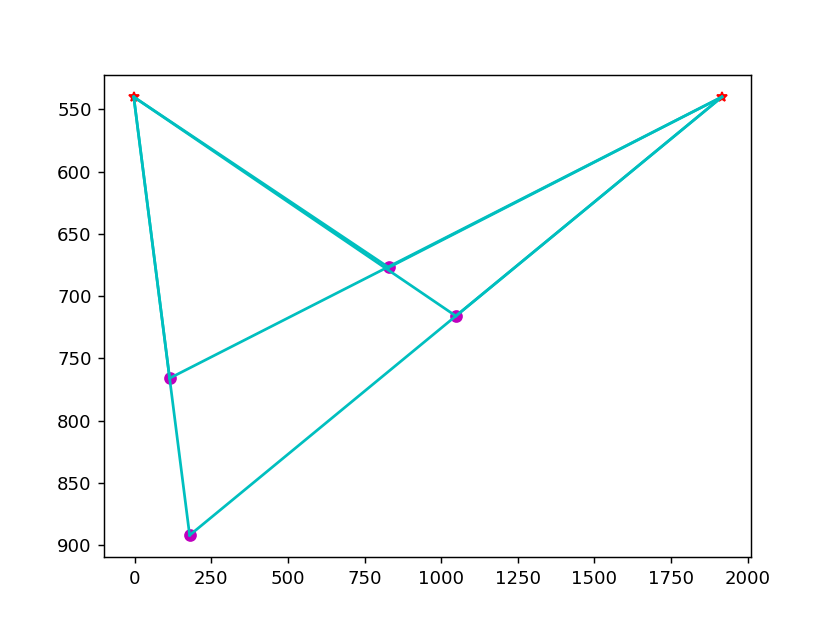

In [11]:
fig1,ax1 = plt.subplots()
ax1.plot(vp1[0],vp1[1],"r*",vp2[0],vp2[1],"r*")
ax1.plot(p[0,0],p[1,0],'om',p[0,1],p[1,1],'om',p[0,2],p[1,2],'om',p[0,3],p[1,3],'om')
ax1.plot(np.array([vp1[0], p[0,0]]), np.array([vp1[1], p[1,0]]),'c')
ax1.plot(np.array([vp1[0], p[0,1]]), np.array([vp1[1], p[1,1]]),'c')
ax1.plot(np.array([vp2[0], p[0,1]]), np.array([vp2[1], p[1,1]]),'c')
ax1.plot(np.array([vp2[0], p[0,2]]), np.array([vp2[1], p[1,2]]),'c')
ax1.plot(np.array([vp1[0], p[0,3]]), np.array([vp1[1], p[1,3]]),'c')
ax1.plot(np.array([vp1[0], p[0,2]]), np.array([vp1[1], p[1,2]]),'c')
ax1.plot(np.array([vp2[0], p[0,0]]), np.array([vp2[1], p[1,0]]),'c')
ax1.plot(np.array([vp2[0], p[0,3]]), np.array([vp2[1], p[1,3]]),'c')
ax1.invert_yaxis()

<IPython.core.display.Javascript object>


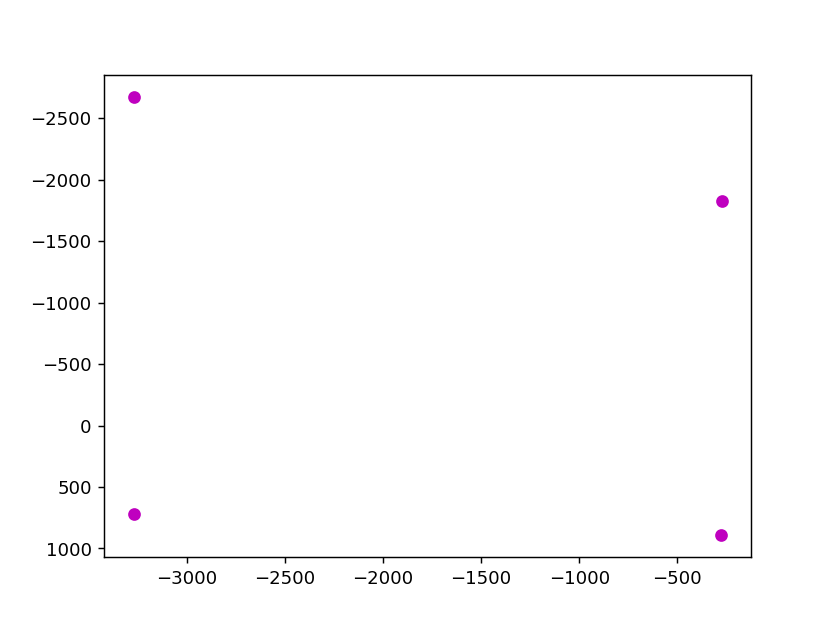

In [12]:
fig2,ax2 = plt.subplots()

ax2.plot(pp[0,0],pp[1,0],'om',pp[0,1],pp[1,1],'om',pp[0,2],p[1,2],'om',pp[0,3],p[1,3],'om')

ax2.invert_yaxis()

Homography Matrix:
[[ 1.94002150e+00 -7.60783183e+02  8.29000000e+02]
 [-1.09296703e+02 -2.18630858e+02  6.77000000e+02]
 [-2.07118300e-01 -4.01606864e-01  1.00000000e+00]]


<IPython.core.display.Javascript object>


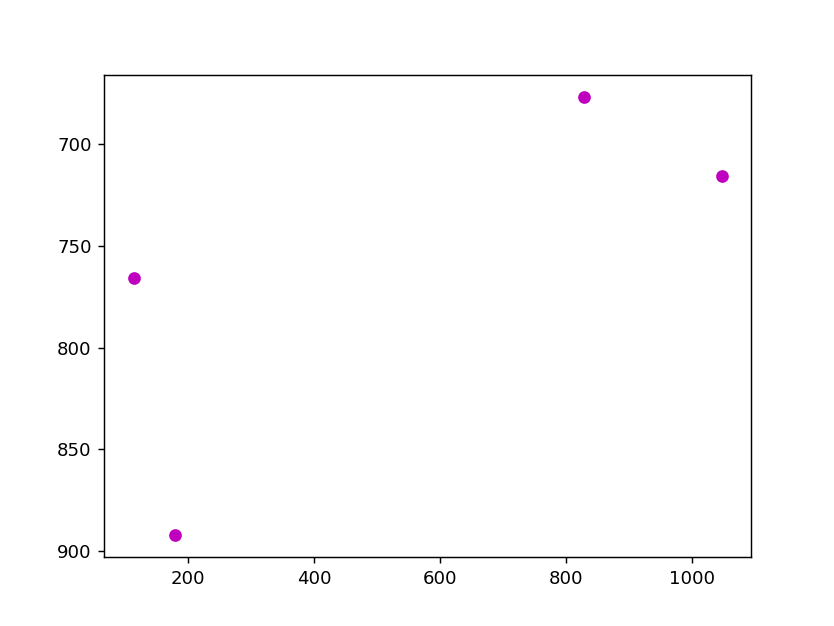

(array([[1.14000000e+02, 8.29000000e+02, 1.04800000e+03, 1.79303223e+02],
        [7.66000000e+02, 6.77000000e+02, 7.16000000e+02, 8.92141296e+02],
        [1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00]]),
 array([[-1.59545099e-04,  3.36404099e-04, -2.18379637e-04,
          3.53910351e-03],
        [-1.28173872e-03, -1.88903840e-03, -1.07700858e-03,
         -1.83219034e-03],
        [ 1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
          1.00000000e+00]]))

In [13]:
# Define the source and destination points for the homography
src_pts = np.float32([pr[:, 0], pr[:, 1], pr[:, 2], pr[:, 3]])
dst_pts = np.float32([p[:, 0], p[:, 1], p[:, 2], p[:, 3]])


# Find the homography matrix
M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)

# Print the homography matrix
print("Homography Matrix:")
print(M)

pm = np.dot(M, pr)
pm = norm_points(pm)

lm = np.dot (np.linalg.inv(M.T), lr)
lm = norm_points(lm)



fig3,ax3 = plt.subplots()

ax3.plot(pm[0,0],pm[1,0],'om',pm[0,1],pm[1,1],'om',pm[0,2],pm[1,2],'om',pm[0,3],pm[1,3],'om')

ax3.invert_yaxis()

pm,lm

In [14]:
for i in range(4):
    point = [int(np.round(pm[0,i])), int(np.round(pm[1,i]))]
    cv2.circle(img, (point[0], point[1]), 8, (255, 0, 255), -1)
    cv2.putText(img, f'p{i+1}', (point[0] + 10, point[1] - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 255), 2)


# Mostrar la imagen
cv2.namedWindow("Ventana1", cv2.WINDOW_NORMAL)
cv2.imshow("Ventana1",img)
cv2.waitKey(0)


QSettings::value: Empty key passed
QSettings::value: Empty key passed


27

In [15]:
cv2.destroyAllWindows()

In [16]:
def def_grid_lines(r0,r1,c0,c1,w,h):
    R=np.linspace(r0,r1,r1-r0+1)
    C=np.linspace(c0,c1,c1-c0+1)
    n = len(R)+len(C)
    l=np.zeros((3, n))
    
    #Definimos primero lineas horizontales
    idx=0
    for i in R:
        l[:,idx]=[0, 1, h*i]
        idx +=1
        
    #Definimos primero lineas verticales
    for i in C:
        l[:,idx]=[1, 0, h*i]
        idx=idx+1
    return l

In [17]:
img = cv2.imread('vp.jpg')

lines = def_grid_lines(-6,6,-6,6,1,1)  # Forma (3, N_líneas)

# 4. Calcular la Homografía para Líneas (H_l)
Hl = np.linalg.inv(M).T  # M = H_p

# 5. Proyectar las Líneas a la Imagen
projected_lines = np.dot(Hl, lines)
projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)  # Normalizar

# # Dibujar puntos proyectados
# for i in range(projected_pts.shape[1]):
#     x, y = int(projected_pts[0, i]), int(projected_pts[1, i])
#     cv2.circle(img, (x, y), 5, (0, 255, 0), -1)

# Dibujar líneas proyectadas
for i in range(projected_lines.shape[1]):
    a, b, c = projected_lines[:, i]
    # Encontrar dos puntos en la línea (para dibujar)
    x0, y0 = 0, int(-c/b) if b != 0 else 0
    x1, y1 = img.shape[1], int((-c - a*img.shape[1])/b) if b != 0 else 0
    cv2.line(img, (x0, y0), (x1, y1), (255, 0, 0), 2)

cv2.namedWindow("Projected Grid", cv2.WINDOW_NORMAL)
cv2.imshow("Projected Grid", img)
cv2.waitKey(0)
cv2.destroyAllWindows()

prolonga las lineas hasta los bordes de la imagen

In [18]:
def get_line_endpoints(line, width, height):
    x1, y1, x2, y2 = line
    line_params = np.polyfit([x1, x2], [y1, y2], 1)
    slope, intercept = line_params

    points = []
    for x in [0, width]:
        y = slope * x + intercept
        if 0 <= y <= height:
            points.append((int(x), int(y)))

    for y in [0, height]:
        x = (y - intercept) / slope
        if 0 <= x <= width:
            points.append((int(x), int(y)))

    if len(points) >= 2:
        return points[0], points[1]
    else:
        return (x1, y1), (x2, y2)

carga todas las lineas guardadas en el archivo lines_near_vps.npy

In [19]:
img = cv2.imread('vp.jpg')

lines_near_vps_no_merged = np.load('lines_near_vps.npy')
lines_near_vps = np.load('merged_lines_near_vps.npy')
#print(lines_near_vps_no_merged.shape, lines_near_vps.shape)
#print(lines_near_vps)


# for line in lines_near_vps_no_merged:
#     x1, y1, x2, y2 = line[0]
#     pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
#     cv2.line(img, pt1, pt2, (0, 0, 255), 1)

# Iterate over each line and draw it on the image
for line in lines_near_vps:
    x1, y1, x2, y2 = line[0]

    pt1 = x1, y1
    pt2 = x2, y2
    # pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 255, 0), 3)  # Green color and line thickness of 2


# Mostrar la imagen con las líneas dibujadas
cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [20]:
cv2.destroyAllWindows()


determina si una linea pasa cerca de un VP

In [21]:
def line_passes_near_vp(line, vp, threshold=10):
    x1, y1, x2, y2 = line
    line_params = np.polyfit([x1, x2], [y1, y2], 1)
    slope, intercept = line_params
    vp_x, vp_y = vp[0], vp[1]
    return abs(vp_y - (slope * vp_x + intercept)) < threshold

separa las lienas que pasan cerca de vp1 y vp2

In [22]:
import numpy as np
import random
import cv2

In [23]:
lines_vp1 = []
lines_vp2 = []

img = cv2.imread('vp.jpg')
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 255, 0), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 255, 0), -1)

for line in lines_near_vps:
    if line_passes_near_vp(line[0], vp1):
        lines_vp1.append(line)
    elif line_passes_near_vp(line[0], vp2):
        lines_vp2.append(line)

# Draw lines passing through vp1
for line in lines_vp1:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (255, 0, 0), 1)  # Blue color for lines passing through vp1

# Draw lines passing through vp2
for line in lines_vp2:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 0, 255), 1)  # Red color for lines passing through vp2

# Display the image with the drawn lines
cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [24]:
def distance_between_lines(line1, line2, img_width, img_height):
    """
    Calculate distance between two lines by extending them to image boundaries
    and computing the distance between their midpoints.

    Args:
        line1: First line (x1, y1, x2, y2)
        line2: Second line (x1, y1, x2, y2)
        img_width: Width of the image
        img_height: Height of the image

    Returns:
        Euclidean distance between the midpoints of the extended lines
    """
    # Get extended endpoints for both lines
    (x1_1, y1_1), (x2_1, y2_1) = get_line_endpoints(line1[0], img_width, img_height)
    (x1_2, y1_2), (x2_2, y2_2) = get_line_endpoints(line2[0], img_width, img_height)

    # Calculate midpoints of extended lines
    mid1 = np.array([(x1_1 + x2_1) / 2, (y1_1 + y2_1) / 2])
    mid2 = np.array([(x1_2 + x2_2) / 2, (y1_2 + y2_2) / 2])

    # Return Euclidean distance between midpoints
    return np.linalg.norm(mid1 - mid2)

def select_lines_with_distance(lines_vp1, img_width, img_height, threshold_min, threshold_max, max_attempts=1000):
    """
    Select two random lines with distance between thresholds.

    Args:
        lines_vp1: List of lines, each as (x1, y1, x2, y2)
        img_width: Image width for line extension
        img_height: Image height for line extension
        threshold_min: Minimum allowed distance between lines
        threshold_max: Maximum allowed distance between lines
        max_attempts: Maximum attempts before giving up

    Returns:
        Tuple of (idx1, idx2, distance) for the selected lines

    Raises:
        ValueError if no suitable pair is found
    """
    n = len(lines_vp1)
    if n < 2:
        raise ValueError("Need at least 2 lines to select a pair")

    for _ in range(max_attempts):
        # Select two distinct random indices
        idx1, idx2 = random.sample(range(n), 2)
        line1 = lines_vp1[idx1]
        line2 = lines_vp1[idx2]

        # Calculate distance between extended lines
        distance = distance_between_lines(line1, line2, img_width, img_height)

        # Check if distance is within desired range
        if threshold_min <= distance <= threshold_max:
            return idx1, idx2, distance

    raise ValueError(f"No valid line pair found after {max_attempts} attempts")

In [25]:
img = cv2.imread('vp.jpg')
cv2.circle(img, (vp1[0], vp1[1]), 5, (0, 255, 0), -1)
cv2.circle(img, (vp2[0], vp2[1]), 5, (0, 255, 0), -1)

# Image dimensions
img_width, img_height = img.shape[1], img.shape[0]
# Distance thresholds
threshold_min = 50
threshold_max = 150

# Select two random lines from lines_vp1
idx1, idx2, distance = select_lines_with_distance(lines_vp1, img_width, img_height, 50, 100)
random_lines_vp1 = [lines_vp1[idx1], lines_vp1[idx2]]
# Select two random lines from lines_vp2
idx1, idx2, distance = select_lines_with_distance(lines_vp2, img_width, img_height, 50, 100)
random_lines_vp2 = [lines_vp2[idx1], lines_vp2[idx2]]

for line in random_lines_vp1:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (255, 0, 0), 1)  # Blue color for lines passing through vp1
for line in random_lines_vp2:
    x1, y1, x2, y2 = line[0]
    pt1, pt2 = get_line_endpoints((x1, y1, x2, y2), img.shape[1], img.shape[0])
    cv2.line(img, pt1, pt2, (0, 0, 255), 1)  # Red color for lines passing through vp2

cv2.namedWindow("Image with Lines", cv2.WINDOW_NORMAL)
cv2.imshow('Image with Lines', img)
cv2.waitKey(0)
cv2.destroyAllWindows()

automatic rankin

In [26]:
from clipBox import *

def sortPts(P):
    theta = np.zeros(4)
    mX = np.mean(P[0,: ])
    mY = np.mean(P[1, :])
    for k in range(4):
        Dx = P[0, k] - mX
        Dy = P[1, k] - mY
        theta[k] = np.arctan2(Dy, Dx)
    
    indices = sorted(range(len(theta)), key = lambda index: theta[index])
    sP = P[:, indices]
    return sP, indices

def sortPtsIdx(p,i,j):
    P = np.array([[p[i, 0, 0],p[i, 0, 2],p[j, 0, 0],p[j, 0, 2]],
                  [p[i, 0, 1],p[i, 0, 3],p[j, 0, 1],p[j, 0, 3]],
                  [  1,                1,         1,        1]]).astype('float64')
    return sortPts(P)

def line_similarity(line_a, line_b, threshold=1, normType = 0, cplB=None):
    distance = np.inf
    pts = None
    if normType == 1:
        # Normalize the lines as homogeneous variable
        linea_n = line_a / line_a[2]
        lineb_n = line_b / line_b[2]
        tmp = linea_n[:2] - lineb_n[:2]
        distance = np.dot(tmp, tmp)
    elif normType == 2:
        # Normalize the lines according to their size
        lineb_n = line_b / np.linalg.norm(line_b)
        linea_n = line_a / np.linalg.norm(line_a)
        tmp = lineb_n - linea_n
        distance = np.dot(tmp, tmp)
    else:
        if cplB == None:
            cplB = clipBox((0,540),(1920,540))
        pl1, pl2, success = cplB.clipLine(line_a)
        
        
        if success == True:
            pl3, pl4, success = cplB.clipLine(line_b)
            
            if success == True:
                
                P = np.hstack([pl1,pl2,pl3,pl4]).reshape(4,3).transpose()
                
                sP, idx = sortPts(P)
                
                d=[]
                tmp = sP[:2,0]-sP[:2,1]
                d.append(np.dot(tmp, tmp)) #Squared Distance between P[0,:] and P[1,:]
                tmp = sP[:2,2]-sP[:2,3]
                d.append(np.dot(tmp, tmp)) #Squared Distance between P[0,:] and P[1,:]
                pts = P.copy()
                if d[0] > d[1]:
                    distance = d[0]
                    pts = np.hstack([pts, np.array(sP[:,0],ndmin=2).transpose()])
                    pts = np.hstack([pts, np.array(sP[:,1],ndmin=2).transpose()])
                else:
                    distance = d[1]
                    pts = np.hstack([pts, np.array(sP[:,2],ndmin=2).transpose()])
                    pts = np.hstack([pts, np.array(sP[:,3],ndmin=2).transpose()])

    # Compute similarity
    print('distance = ', distance)
    return distance <= (threshold * threshold), distance, pts

In [27]:
def points_to_homogeneous_line(x1, y1, x2, y2):
    return np.cross([x1, y1, 1], [x2, y2, 1])

In [28]:
def order_lines_by_intersection(lines, horizon_y=540, offset=10):
    H10 = np.array([0, 1, -(horizon_y + offset)])  # Línea horizontal

    intersections = []
    for line in lines:
        intersection = np.cross(line, H10)
        intersection = intersection / intersection[-1]  # Normalizar
        intersections.append(intersection)

    # Ordenar las líneas según la coordenada x de las intersecciones
    sorted_indices = np.argsort([pt[0] for pt in intersections])  # Ordenar por x
    ordered_lines = [lines[i] for i in sorted_indices]
    return ordered_lines

In [29]:
def main_process(lines_near_vps, vp1, vp2, thr=1, iterations=100, grid_size=5, region=[1920, 1080]):
    results = []

    for it in range(iterations):
        # Step 1: Select random lines
        # Select two random lines from lines_vp1
        idx1, idx2, distance = select_lines_with_distance(lines_vp1, img_width, img_height, 50, 100)
        random_lines_vp1 = [lines_vp1[idx1], lines_vp1[idx2]]
        # Select two random lines from lines_vp2
        idx1, idx2, distance = select_lines_with_distance(lines_vp2, img_width, img_height, 50, 100)
        random_lines_vp2 = [lines_vp2[idx1], lines_vp2[idx2]]
        homogeneous_lines = [points_to_homogeneous_line(*line[0]) for line in random_lines_vp1 + random_lines_vp2]
        # print(homogeneous_lines)

        ordered_lines = order_lines_by_intersection(homogeneous_lines)

        # Step 2: Find intersections
        l1 = ordered_lines[1]
        l2 = ordered_lines[0]
        l3 = ordered_lines[2]
        l4 = ordered_lines[3]

        p1 = np.cross(l2, l3)
        p2 = np.cross(l1, l3)
        p3 = np.cross(l1, l4)
        p4 = np.cross(l2, l4)

        p = np.zeros((3, 4))
        p[:, 0] = p1
        p[:, 1] = p2
        p[:, 2] = p3
        p[:, 3] = p4
        p = norm_points(p)

        # Define the square of 1x1
        pr = np.ones((3,4))
        pr[:2,0] = [0., 1]
        pr[:2,1] = [0., 0.]
        pr[:2,2] = [1, 0.]
        pr[:2,3] = [1, 1.]
        pr = norm_points(pr)

        # Compute homography M

        src_pts = np.float32([pr[:, 0], pr[:, 1], pr[:, 2], pr[:, 3]])
        dst_pts = np.float32([p[:, 0], p[:, 1], p[:, 2], p[:, 3]])
        M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC)


        # Step 3: Project grid
        grid_lines = def_grid_lines(-grid_size, grid_size, -grid_size, grid_size, 1, 1)

        try:
            Hl = np.linalg.inv(M).T
        except np.linalg.LinAlgError:
            continue

        projected_lines = np.dot(Hl, grid_lines)
        projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)

        # Step 4: Compare lines
        similarities = 0
        Dist = 0
        cpl = clipBox((0,region[1]//2),(region[0], region[1]//2))
        for line in projected_lines.T:
            for original_line in lines_near_vps:
                original_line =original_line[0]
                homogeneous_line = points_to_homogeneous_line(original_line[0], original_line[1], original_line[2], original_line[3])

                isSimil,d,_ = line_similarity(line, homogeneous_line, threshold = thr, normType = 0, cplB = cpl)
                #isSimil,d,_ = line_similarity_old(line, homogeneous_line, 0.2)
                if isSimil:
                    similarities += 1
                    Dist += d
                    break

        # Step 5: Save results
        results.append((similarities, Dist/similarities, M, it))

    # Step 6: Rank results
    results.sort(key=lambda x: x[0], reverse=True)
    return results

In [30]:
# Load data
lines_near_vps = np.load('merged_lines_near_vps.npy')
vp1 = np.array([-3, 540, 1])
vp2 = np.array([1916, 540, 1])

In [31]:
# Run the process
best_results = main_process(lines_near_vps, vp1, vp2, thr=2, iterations=100, grid_size=5, region=(1920,1080))

distance =  3691277.3196437024
distance =  3755511.670968876
distance =  1247248.6019395052
distance =  3772286.2125569233
distance =  3613819.0859096316
distance =  1532990.8668482613
distance =  1582723.041800119
distance =  1236384.0
distance =  3669757.3255190547
distance =  1613829.4256055367
distance =  3773895.1199703184
distance =  1179204.526935265
distance =  3761478.123514182
distance =  3790613.9190777657
distance =  3741909.4312281124
distance =  3830532.114282814
distance =  3830063.0785182393
distance =  3830379.7528472557
distance =  3818742.781163435
distance =  3714088.96
distance =  3704554.0166204986
distance =  3717061.2843801654
distance =  3742241.325443787
distance =  3833856.0
distance =  3734261.4758671094
distance =  3741909.4312281124
distance =  3743744.8284131894
distance =  2204286.917484327
distance =  2222552.748209422
distance =  2133618.8635195536
distance =  2198292.6666404973
distance =  2237059.6342091057
distance =  2198496.263267353
distance =  2

distance =  3692393.052291489
distance =  3656859.6120386003
distance =  3686400.918382109
distance =  3667993.250820847
distance =  3814101.460022491
distance =  3675387.392274135
distance =  3785081.090174688
distance =  3656722.6164342472
distance =  3798813.210911846
distance =  3803263.754295841
distance =  3721597.780086022
distance =  3796109.9859048394
distance =  3796688.7039261106
distance =  3796042.891128667
distance =  3783075.5784209715
distance =  3699565.6584578305
distance =  3693278.627694318
distance =  3718988.0853334563
distance =  3720445.420222954
distance =  3797037.1974529857
distance =  3785511.642131908
distance =  3721597.780086022
distance =  3805207.1999494187
distance =  47420.48517506801
distance =  62289.6873705079
distance =  1.5716735205682887e-07
distance =  3729862.854492303
distance =  3803294.8380566584
distance =  3686401.3561414373
distance =  3808276.110057159
distance =  3697539.441271386
distance =  3656863.556531887
distance =  3686400.00128

distance =  559177.5129042208
distance =  495252.0419884771
distance =  67349.39261776996
distance =  492811.9304414633
distance =  3613819.0859096316
distance =  13439.855293398861
distance =  10076.482322466023
distance =  68129.59542430432
distance =  482084.66581217316
distance =  7235.8032231968455
distance =  495125.8768019703
distance =  82911.81934382499
distance =  488278.4450834771
distance =  486332.2328853439
distance =  554781.945868344
distance =  489522.51659673953
distance =  489252.1249081368
distance =  489554.00969841407
distance =  496243.01487303094
distance =  3714088.96
distance =  3704554.0166204986
distance =  559071.5843190143
distance =  556643.4320704936
distance =  489090.3743190143
distance =  494890.19423747464
distance =  554781.945868344
distance =  485520.6282252643
distance =  3686417.9613586674
distance =  3686417.9273935566
distance =  3686413.367252855
distance =  3587960.269864097
distance =  3591051.4464568943
distance =  3526808.9336738405
dista

distance =  23378.82304095637
distance =  24615.62003866545
distance =  3833856.0
distance =  3734261.4758671094
distance =  3741909.4312281124
distance =  3743744.8284131894
distance =  94284.71802383126
distance =  112550.54874892575
distance =  3687162.879366674
distance =  88290.46718000132
distance =  127057.43474860956
distance =  88494.06380685706
distance =  130031.72811039719
distance =  94768.2038568075
distance =  86624.45145027552
distance =  113164.15921605789
distance =  3689535.848725229
distance =  3689315.854127965
distance =  3688248.8838430103
distance =  3689424.851426597
distance =  3689535.848725229
distance =  3690755.8217115514
distance =  3690243.8325170227
distance =  3688703.8703361712
distance =  3689208.8568293327
distance =  3689648.8460238613
distance =  3689103.8595307004
distance =  3691277.3196437024
distance =  3755511.670968876
distance =  1247248.6019395052
distance =  3772286.2125569233
distance =  3613819.0859096316
distance =  1532990.8668482613


distance =  3687103.1243768893
distance =  3697828.6599877784
distance =  3526782.696427865
distance =  3699421.9207374416
distance =  3703157.4082855033
distance =  3497886.331844198
distance =  3526786.9424021016
distance =  3508775.466726592
distance =  3709046.696916657
distance =  3516007.4317335323
distance =  3697906.906411542
distance =  3497752.347092823
distance =  3702890.5608953503
distance =  3704621.8128631804
distance =  3686770.7358108615
distance =  3701865.3505329266
distance =  3702083.1079522492
distance =  3701840.1659355196
distance =  3697228.8480449663
distance =  3694886.741471252
distance =  3701758.0804213723
distance =  3687093.9806267917
distance =  3686899.5763359535
distance =  3702214.6942631197
distance =  3698054.2388846357
distance =  3686770.7358108615
distance =  3705394.0734413173
distance =  1767.1232730183683
distance =  1824.4691401016366
distance =  42793.18352634237
distance =  262.8173774706794
distance =  4326.744406878598
distance =  1.6460

...

distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3691277.3196437024
distance =  3755511.670968876
distance =  1247248.6019395052
distance =  3772286.2125569233
distance =  3613819.0859096316
distance =  1532990.8668482613
distance =  1582723.041800119
distance =  1236384.0
distance =  3669757.3255190547
distance =  1613829.4256055367
distance =  3773895.1199703184
distance =  1179204.526935265
distance =  3761478.123514182
distance =  3790613.9190777657
distance =  3741909.4312281124
distance =  3830532.114282814
distance =  3830063.0785182393
distance =  3830379.7528472557
distance =  3818742.781163435
distance =  3714088.96
distance =  3704554.0166204986
distance =  3717061.2843801654
distance =  3742241.325443787
distance =  3833856.0
distance =  3734261.4758671094
distance =  3741909.4312281124
distance =  3743744.8284131894
distance =  2563213.853046875
distance =  2581479.6837719698
distance =  2492545.7990821013
distance =  2557

distance =  3809304.759486542
distance =  1175853.400236288
distance =  3824578.048522436
distance =  3829507.634244168
distance =  3736599.7470363337
distance =  3821579.217074237
distance =  3822221.5235029734
distance =  3821504.739216615
distance =  3807065.397704825
distance =  3709256.5986866723
distance =  3700651.5316321775
distance =  3733473.372747701
distance =  3735221.6852770266
distance =  3822608.228359171
distance =  3809785.204633937
distance =  3736599.7470363337
distance =  3831657.4010125506
distance =  3053702.134902327
distance =  3053702.142170949
distance =  3053703.5263742963
distance =  2964142.399039779
distance =  2966952.102619415
distance =  2908584.4494135855
distance =  2927874.605509921
distance =  3039889.0516934237
distance =  3053721.6122122747
distance =  3052572.2774208463
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686403.748136585
distance =  3686400.0
distance =  3686

distance =  1127224.8749644894
distance =  1145490.7056895837
distance =  1056556.8209997155
distance =  1121230.6241206594
distance =  1159997.5916892677
distance =  1121434.220747515
distance =  1162971.885051055
distance =  1127708.3607974655
distance =  1119564.6083909336
distance =  1146104.3161567159
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3686400.0
distance =  3691277.3196437024
distance =  3755511.670968876
distance =  1247248.6019395052
distance =  3772286.2125569233
distance =  3613819.0859096316
distance =  1532990.8668482613
distance =  1582723.041800119
distance =  1236384.0
distance =  3669757.3255190547
distance =  1613829.4256055367
distance =  3773895.1199703184
distance =  1179204.526935265
distance =  3761478.123514182
distance =  3790613.9190777657
distance =  3741909.431228112

distance =  3686417.7410524935
distance =  3686404.893000977
distance =  3686400.0
distance =  3686410.3170267353
distance =  3686417.7410524935
distance =  3686601.981310074
distance =  3686504.285207042
distance =  3686400.0
distance =  3686401.468975219
distance =  3686427.165078251
distance =  3686400.044949461
distance =  3691277.3196437024
distance =  3755511.670968876
distance =  1247248.6019395052
distance =  3772286.2125569233
distance =  3613819.0859096316
distance =  1532990.8668482613
distance =  1582723.041800119
distance =  1236384.0
distance =  3669757.3255190547
distance =  1613829.4256055367
distance =  3773895.1199703184
distance =  1179204.526935265
distance =  3761478.123514182
distance =  3790613.9190777657
distance =  3741909.4312281124
distance =  3830532.114282814
distance =  3830063.0785182393
distance =  3830379.7528472557
distance =  3818742.781163435
distance =  3714088.96
distance =  3704554.0166204986
distance =  3717061.2843801654
distance =  3742241.3254

distance =  3832755.4441261613
distance =  3819451.7637542323
distance =  3741909.4312281124
distance =  3842130.311785414
distance =  71665.99308559988
distance =  89713.19947907203
distance =  2494.2711877924194
distance =  65749.31182971124
distance =  104061.60224489149
distance =  65950.21857791001
distance =  107004.76798732961
distance =  72143.3625754968
distance =  64105.46132840366
distance =  90319.86286432268
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3686400.034077944
distance =  3691277.3196437024
distance =  3755511.670968876
distance =  1247248.6019395052
distance =  3772286.2125569233
distance =  3613819.0859096316
distance =  1532990.8668482613
distance =  1582723.041800119
distance =  1236384.0
distance

In [32]:

# Print the top 5 results
for i, (similarities, d, M, it) in enumerate(best_results[:5]):
    print(f"Rank {i+1}: Similarities = {similarities}")
    print("Dist promedio: ", d)
    print("Iteracion: ", it)
    print("Matrix M:")
    print(M)

Rank 1: Similarities = 5
Dist promedio:  0.23194664769078632
Iteracion:  0
Matrix M:
[[-4.67943547e+00 -1.24848216e+03  1.55721729e+03]
 [-3.87933624e+01 -3.61372370e+02  5.83573425e+02]
 [-7.14088588e-02 -6.64122829e-01  1.00000000e+00]]
Rank 2: Similarities = 5
Dist promedio:  0.23194664769078632
Iteracion:  17
Matrix M:
[[-4.67943547e+00 -1.24848216e+03  1.55721729e+03]
 [-3.87933624e+01 -3.61372370e+02  5.83573425e+02]
 [-7.14088588e-02 -6.64122829e-01  1.00000000e+00]]
Rank 3: Similarities = 5
Dist promedio:  0.5327613630607694
Iteracion:  25
Matrix M:
[[-4.99129610e+00 -1.23847650e+03  1.55721729e+03]
 [-4.13780516e+01 -3.54171149e+02  5.83573425e+02]
 [-7.61665835e-02 -6.53237527e-01  1.00000000e+00]]
Rank 4: Similarities = 5
Dist promedio:  0.023673047334092038
Iteracion:  31
Matrix M:
[[-4.16425455e+00 -1.25573741e+03  1.55721729e+03]
 [-3.45187677e+01 -3.66594075e+02  5.83573425e+02]
 [-6.35402965e-02 -6.72015912e-01  1.00000000e+00]]
Rank 5: Similarities = 5
Dist promedio:  

In [33]:
for i, (similarities, d, M, it) in enumerate(best_results[:5]):
    img = cv2.imread('vp.jpg')
    lines = def_grid_lines(-5,5,-5,5,1,1)
    Hl = np.linalg.inv(M).T
    projected_lines = np.dot(Hl, lines)
    projected_lines = projected_lines / np.linalg.norm(projected_lines, axis=0)
    # Dibujar líneas proyectadas
    for i in range(projected_lines.shape[1]):
        a, b, c = projected_lines[:, i]
        # Encontrar dos puntos en la línea (para dibujar)
        x0, y0 = 0, int(-c/b) if b != 0 else 0
        x1, y1 = img.shape[1], int((-c - a*img.shape[1])/b) if b != 0 else 0
        cv2.line(img, (x0, y0), (x1, y1), (255, 0, 0), 2)

    cv2.namedWindow("Projected Grid", cv2.WINDOW_NORMAL)
    cv2.imshow("Projected Grid", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()